# Scaling and RAM: how far does each tool go?

> Backs **Figure 1B** and **Supplementary Figure S2**.

This notebook measures how runtime and memory usage change as the number of queries increases. fastCDS is fairly compared with four other protein-to-genome mapping tools, with every method run single-threaded, on the same machine, using the same query sets.

Each tool was tested up to the largest workload it could complete in a reasonable amount of time and memory. fastCDS reaches 1,000,000 queries; the Bioconductor implementations (`ensembldb::proteinToGenome` and `GenomicFeatures::proteinToGenome`) and geneplot reach 10,000; and the Ensembl REST API reaches 1,000.

The second half of the notebook looks at two fastCDS features that cannot be compared directly because the other tools do not provide them: OpenMP multithreading (`--threads`) and memory-limited processing with `--batch-size`.

All figures are generated from the raw benchmark results in `benchmarks/matched/` and `benchmarks/threads_batch_grid.py`.

## Setup

In [1]:
# Force the inline backend - under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure ...>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Every figure saved as PNG also gets a vector PDF (same bbox/dimensions) under
# reproduce_paper/figures/ (right next to these notebooks), so the
# paper figures are available as scalable PDFs without changing any plotting code.
from pathlib import Path as _Path
import os as _os
FIGDIR = (_Path(_os.environ.get("FASTCDS_REPO") or (_Path.home() / "Desktop" / "fastCDS"))
          / "reproduce_paper" / "figures")
FIGDIR.mkdir(parents=True, exist_ok=True)
if not getattr(mpl.figure.Figure.savefig, "_writes_pdf", False):  # guard: don't double-wrap
    _orig_savefig = mpl.figure.Figure.savefig
    def _savefig_both(self, fname, *a, **k):
        _orig_savefig(self, fname, *a, **k)
        s = str(fname)
        if s.lower().endswith(".png"):
            kk = dict(k); kk.pop("dpi", None)              # vector PDF: drop raster dpi
            _orig_savefig(self, str(FIGDIR / (_os.path.splitext(_os.path.basename(s))[0] + ".pdf")), *a, **kk)
    _savefig_both._writes_pdf = True
    mpl.figure.Figure.savefig = _savefig_both

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly - we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'fastCDS':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'accent':      '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import pandas as pd
from pathlib import Path

DATA = Path.home() / "Desktop" / "fastCDS_data"
# Matched scaling: every tool measured on the SAME machine, the
# SAME query sets, single-threaded, end-to-end (wall + peak RSS via wait4).
# Tools too slow / too memory-hungry at a given N were stopped there.
SCAL = DATA / "bench" / "scaling_matched.tsv"
# Combined threads x batch-size grid (benchmarks/threads_batch_grid.py).
GRID = DATA / "bench" / "threads_batch_grid.tsv"

assert SCAL.exists(), f"missing {SCAL} (run benchmarks/matched/run_matched_scaling.py)"
assert GRID.exists(), f"missing {GRID} (run benchmarks/threads_batch_grid.py)"
print(f"scaling : {SCAL}")
print(f"grid    : {GRID}")

scaling : /home/goguxor/Desktop/fastCDS_data/bench/scaling_matched.tsv
grid    : /home/goguxor/Desktop/fastCDS_data/bench/threads_batch_grid.tsv


## 1. Wall time and memory vs. number of queries

This is a matched comparison: every tool was run single-threaded, on the same machine, using the same protein-coordinate query sets. Runtime (wall clock) and peak memory usage (RSS, measured with wait4) were recorded for each run. The number of queries was increased from 100 to 1,000,000, and each tool was benchmarked until it reached the largest workload it could complete within a practical time and memory budget.

- **fastCDS** completed all benchmarks up to 1,000,000 queries.
- **ensembldb** and **GenomicFeatures** completed up to 10,000 queries. Although both expose proteinToGenome, they use different implementations. The standard ensembldb workflow queries the underlying SQLite database for every request (~28 min at 10,000 queries). In contrast, GenomicFeatures first builds an in-memory GRangesList of CDS regions (~7 s one-time cost) and then performs all mappings in memory, making it about five times faster per query (~6 min at 10,000 queries) while producing identical coordinates. Even so, both remain orders of magnitude slower than fastCDS.
- **Ensembl REST API** completed up to 1,000 queries. Because requests are rate-limited to about one query per second, larger workloads quickly become impractical.
- **geneplot** completed up to 10,000 queries. After building a one-time gffutils genome database, each query still requires a per-gene transcript-to-genome traversal (~0.12 s/query), so scaling to 100,000 queries would take several hours.

Across every workload where comparisons are possible, **fastCDS** is the fastest tool, and the performance gap increases with dataset size because, once its index has been loaded, each additional query takes only a few microseconds.

/tmp/ipykernel_3212588/2890972332.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.05, 1, 0.96])


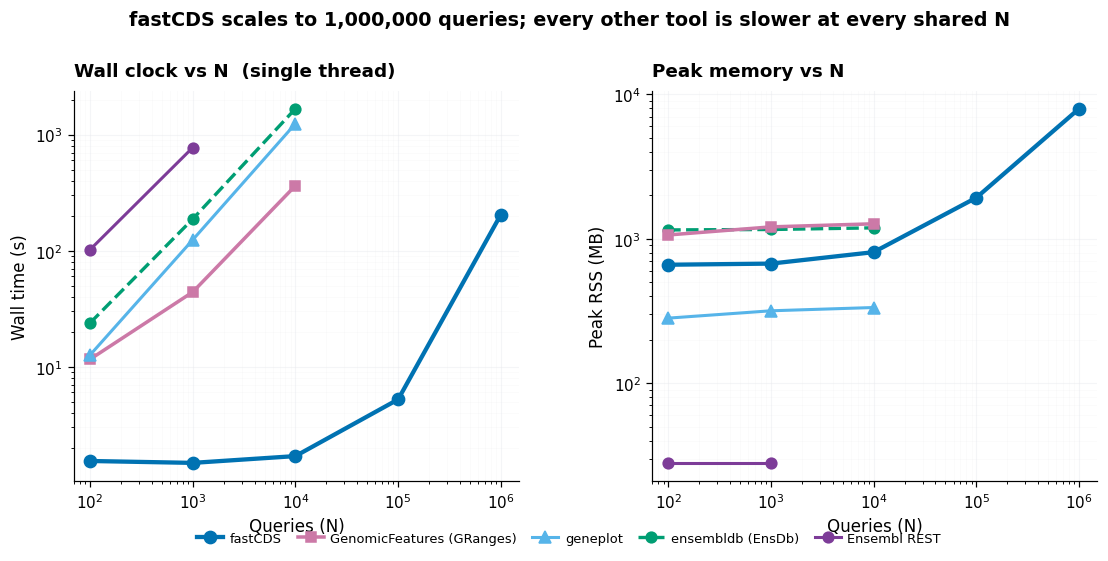

In [2]:
# Matched ladder: every tool, same machine, same queries, one thread.
s = pd.read_csv(SCAL, sep="\t").sort_values(["tool", "n"])
# keep only the tools in the paper's speed/scaling comparison
s = s[s.tool.isin(["fastCDS", "genomicfeatures", "ensembldb", "geneplot", "rest"])]

# Per-tool style. >=2 measured N -> line+markers; a single N -> diamond.
# Two Bioconductor proteinToGenome routes are timed separately: 'ensembldb' is the
# naive EnsDb call (hits the SQLite DB), 'GenomicFeatures (GRanges)' precomputes a
# CDS-by-transcript GRangesList once and maps in-memory (~5x faster per query).
STYLE = {
    "fastCDS":       dict(c=COLORS['fastCDS'], lw=2.8, ms=8, ls="-",  mk="o", z=6, label="fastCDS"),
    "genomicfeatures": dict(c=COLORS['rest'],      lw=2.3, ms=7, ls="-",  mk="s", z=5, label="GenomicFeatures (GRanges)"),
    "geneplot":        dict(c=COLORS['neutral'],   lw=2.0, ms=8, ls="-",  mk="^", z=5, label="geneplot"),
    "ensembldb":       dict(c=COLORS['ensembldb'], lw=2.2, ms=7, ls="--", mk="o", z=4, label="ensembldb (EnsDb)"),
    "rest":            dict(c='#7d3c98',           lw=2.0, ms=7, ls="-",  mk="o", z=5, label="Ensembl REST"),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={'wspace': 0.30})
for tool, st in STYLE.items():
    d = s[s.tool == tool].sort_values("n")
    if len(d) >= 2:
        axes[0].plot(d.n, d.wall_s, marker=st["mk"], ls=st["ls"], color=st["c"],
                     lw=st["lw"], ms=st["ms"], label=st["label"], zorder=st["z"])
    else:
        axes[0].plot(d.n, d.wall_s, "D", color=st["c"], ms=st["ms"] + 1, zorder=st["z"],
                     label=f"{st['label']} (1 N)")
    dr = d[d.rss_mb.notna()]
    if len(dr) >= 2:
        axes[1].plot(dr.n, dr.rss_mb, marker=st["mk"], ls=st["ls"], color=st["c"],
                     lw=st["lw"], ms=st["ms"], label=st["label"], zorder=st["z"])
    elif len(dr) == 1:
        axes[1].plot(dr.n, dr.rss_mb, "D", color=st["c"], ms=st["ms"] + 1, zorder=st["z"],
                     label=f"{st['label']} (1 N)")

for ax in axes:
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("Queries (N)")
    ax.set_xlim(70, 1.5e6)
    ax.grid(which='major', alpha=0.4, lw=0.7); ax.grid(which='minor', alpha=0.2, lw=0.5)
axes[0].set_ylabel("Wall time (s)")
axes[0].set_title("Wall clock vs N  (single thread)", loc='left')
axes[1].set_ylabel("Peak RSS (MB)")
axes[1].set_title("Peak memory vs N", loc='left')
# One shared legend BELOW both panels so it never sits on top of a curve.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.04),
           ncol=5, fontsize=8.5, framealpha=0.95, columnspacing=1.2, handletextpad=0.5)

fig.suptitle("fastCDS scales to 1,000,000 queries; every other tool is slower at every shared N",
             fontsize=12.5, fontweight='semibold', y=1.04)
fig.tight_layout(rect=[0, 0.05, 1, 0.96])
fig.savefig(DATA / "Figure_S2A_scaling.png", bbox_inches="tight")
plt.show()

## 2. Parallelism and memory: `--threads` × `--batch-size` together

This section explores the two performance controls available in fastCDS. Rather than testing them separately, both are varied together so you can see how they interact.

- `--threads` uses OpenMP to process queries in parallel, reducing runtime as more CPU cores are used.
- `--batch-size` limits peak memory usage by writing results to disk in chunks and freeing each chunk before continuing. Setting `--batch-size` 0 (or omitting the option) processes everything in a single batch. The output is byte-for-byte identical in both cases.

The figure can be read in two directions:

- **Down each column**: increasing the number of threads reduces runtime.
- **Across each row**: decreasing the batch size reduces peak memory usage.

/tmp/ipykernel_3212588/532949558.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


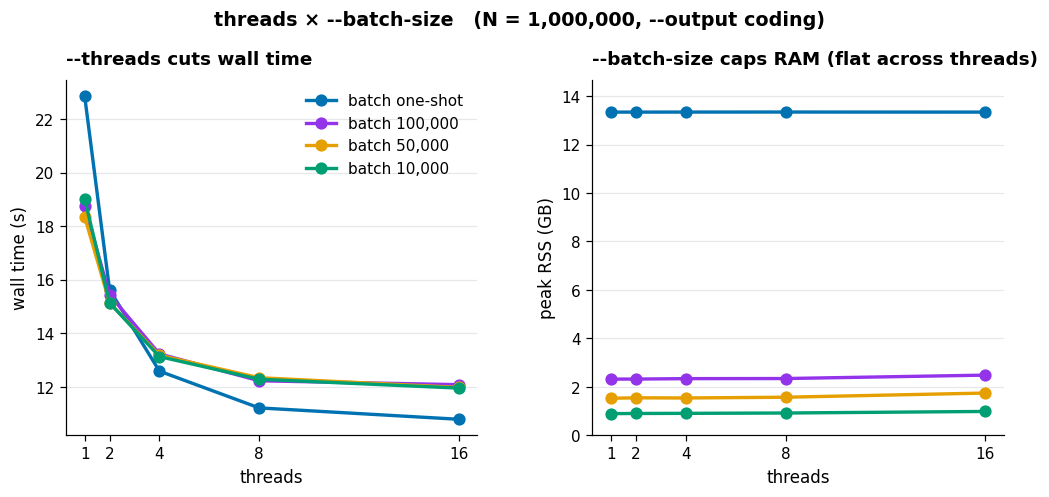

In [3]:
g = pd.read_csv(GRID, sep="\t")
g["peak_rss_gb"] = g["peak_rss_mb"] / 1024

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2),
                       gridspec_kw={'wspace': 0.28})
# colour by batch size; show whichever batch labels are present
palette = [COLORS['fastCDS'], '#9333ea', COLORS['accent'], COLORS['good']]
order = [b for b in ["one-shot", "100,000", "50,000", "10,000"]
         if b in set(g.batch_label)]
cmap = {lab: palette[i] for i, lab in enumerate(order)}
xt = sorted(g.threads.unique())
for lab in order:
    s = g[g.batch_label == lab].sort_values("threads")
    ax[0].plot(s.threads, s.wall_s, "o-", color=cmap[lab], lw=2.2,
               markersize=7, label=f"batch {lab}")
    ax[1].plot(s.threads, s.peak_rss_gb, "o-", color=cmap[lab], lw=2.2,
               markersize=7, label=f"batch {lab}")
ax[0].set_xlabel("threads"); ax[0].set_ylabel("wall time (s)")
ax[0].set_title("--threads cuts wall time", loc="left")
ax[0].set_xticks(xt); ax[0].legend()
ax[1].set_xlabel("threads"); ax[1].set_ylabel("peak RSS (GB)")
ax[1].set_title("--batch-size caps RAM (flat across threads)", loc="left")
ax[1].set_xticks(xt); ax[1].set_ylim(0, g.peak_rss_gb.max() * 1.1)
fig.suptitle(f"threads × --batch-size   (N = 1,000,000, --output coding)",
             fontsize=12.5, fontweight='semibold', y=1.03)
fig.tight_layout()
fig.savefig(DATA / "Figure_S2C_threads_batch.png", bbox_inches="tight")
plt.show()

## Summary

These benchmarks were run on a 32-core workstation with 125 GB RAM using 1,000,000 queries, ensuring that all runs remained in memory and reflected only the computational trade-off between runtime and RAM usage.

- **`--threads`** reduces runtime. Performance improves steadily up to 16 threads, reducing runtime from 22.9 s to 10.8 s (~2.1×), with most of the benefit already achieved using 2 threads (~1.5×). Beyond 16 threads, speedup levels off because output writing and memory bandwidth become the main bottlenecks. In general, setting --threads to the number of physical CPU cores gives the best performance.

- **`--batch-size`** controls peak memory usage independently of thread count. Processing all queries in one batch requires about 13 GB RAM, whereas `--batch-size` 100000, 50000, and 10000 reduce peak memory to approximately 2.4 GB, 1.6 GB, and 0.9 GB, respectively. All settings produce identical output.
- Larger batches are slightly faster but use more memory. This reflects the expected trade-off: fewer writes to disk improve runtime at the cost of higher RAM usage. The only exception is the single-threaded case, where processing everything in one batch is actually the slowest configuration because the large working set places additional pressure on memory allocation.
- If both CPU cores and RAM are plentiful, processing everything in one batch is the fastest option. Otherwise, `--batch-size 10000` reduces peak memory by roughly 14× while increasing runtime by only 10-15%, making it a good default for large datasets or memory-constrained systems.
- As shown in Section 1, runtime scales linearly with the number of queries once the index has been loaded. The ~1.3 s runtime observed for small workloads is dominated by this one-time index loading step.